# 1. Préparation et Visualisation des Données

Dimension des exemples : 2
Nombre de classes : 3
Exemples d'apprentissage : 210
Exemples de test : 90


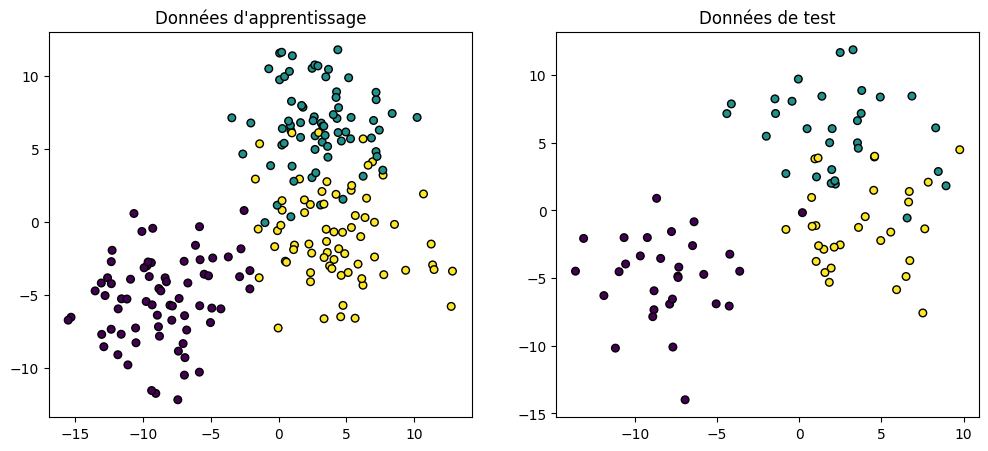

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Charger les données
data = np.loadtxt('dataset.dat')

# Les 2 premières colonnes = features (coordonnées x, y)
X = data[:, :2]
# La 3e colonne = le label (classe 0, 1 ou 2)
y = data[:, 2]

# 2. Séparer en train (70%) et test (30%)
# stratify=y → assure que les proportions de classes sont conservées
# random_state → fixe le hasard pour avoir des résultats reproductibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Infos de base
print(f"Dimension des exemples : {X.shape[1]}")  # 2
print(f"Nombre de classes : {len(np.unique(y))}")  # 3
print(f"Exemples d'apprentissage : {X_train.shape[0]}")
print(f"Exemples de test : {X_test.shape[0]}")

# 4. Visualiser
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=30)
axes[0].set_title("Données d'apprentissage")

axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=30)
axes[1].set_title("Données de test")

plt.show()

# 2. Classification avec le Plus Proche Voisin (1-PPV)

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# a) Définir le classifieur 1-PPV
one_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute')

# b) L'entraîner sur les données d'apprentissage
# "fit" = "apprends ces données" → pour KNN, ça veut juste dire "stocke les points" (pas de vrai calcul, c'est un algorithme "lazy")
one_NN.fit(X_train, y_train)

# c) Évaluer : score = taux de reconnaissance (accuracy)
score_train = one_NN.score(X_train, y_train)
score_test = one_NN.score(X_test, y_test)

print(f"Score train : {score_train:.2%}")  # → 100% (attendu !)
print(f"Score test  : {score_test:.2%}")

# Matrice de confusion sur le test
y_pred = one_NN.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrice de confusion :\n{cm}")

Score train : 100.00%
Score test  : 82.22%

Matrice de confusion :
[[29  0  1]
 [ 0 21  9]
 [ 0  6 24]]


# 3. Visualisation des Frontières de Décision pour 1-PPV

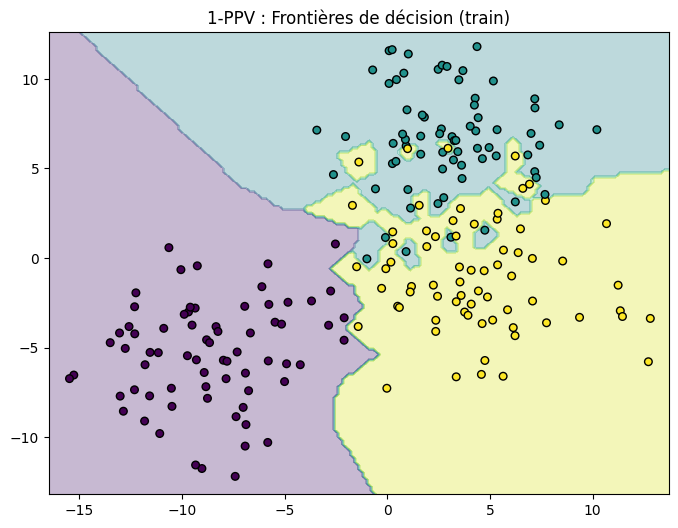

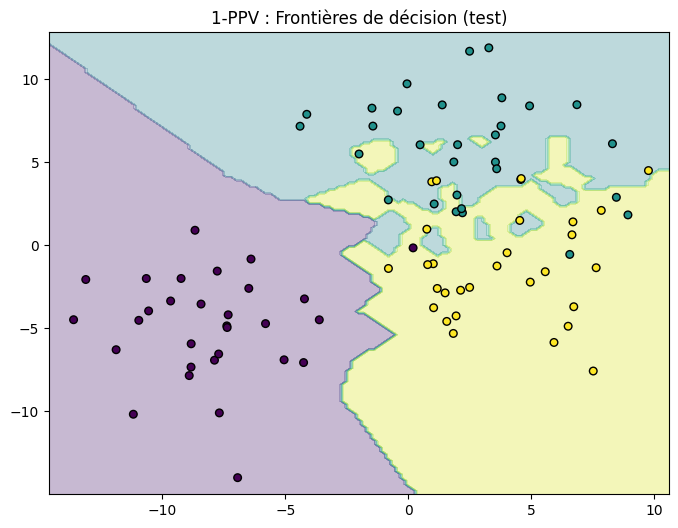

In [3]:
import numpy as np

def plot_boundary(clf, X, y, title=""):
    # Créer une grille fine couvrant tout l'espace des données
    h = 0.2  # pas de la grille
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    # Classer chaque point de la grille
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Colorier les zones + afficher les points
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=30)
    plt.title(title)
    plt.show()

# d) Frontières avec données d'apprentissage
plot_boundary(one_NN, X_train, y_train,
              "1-PPV : Frontières de décision (train)")

# e) Frontières (apprises sur train) + données de test superposées
# → les points mal classés sont ceux qui tombent dans une zone de
#   mauvaise couleur
plot_boundary(one_NN, X_test, y_test,
              "1-PPV : Frontières de décision (test)")

# 4. Explication du Diagramme de Voronoï

Avec k=1, pour classer un point inconnu, on cherche le seul point d'entraînement le plus proche. Donc chaque point d'entraînement "possède" une zone autour de lui comme une petite îles, c'est ce qu'on appelle un diagramme de Voronoï.

# 5. Impact de la Taille du Jeu d'Apprentissage

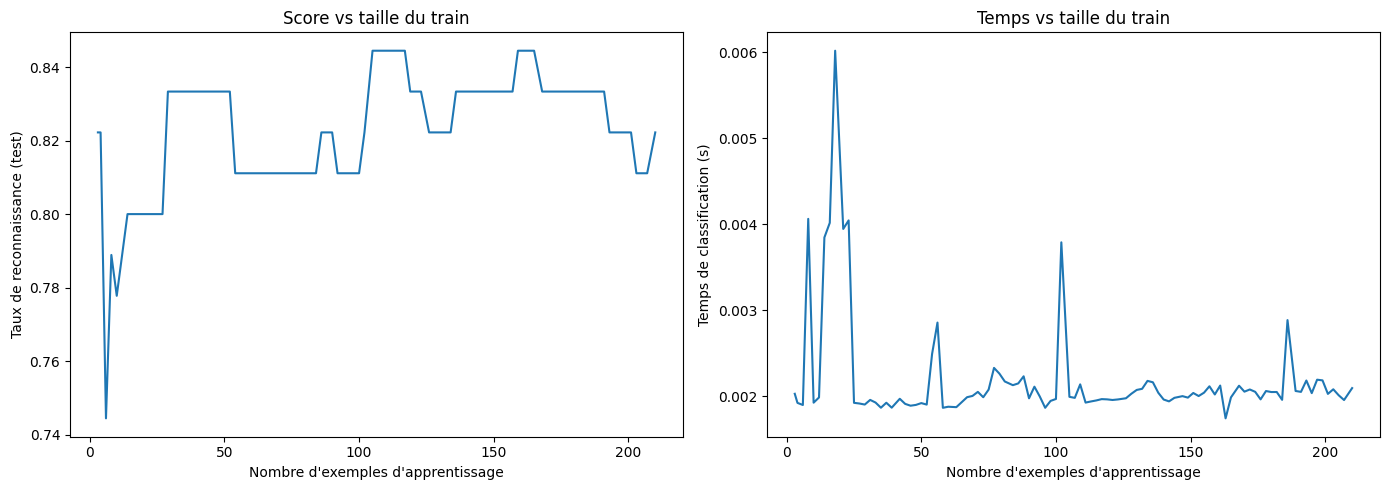

In [6]:
from sklearn.model_selection import train_test_split as tts
import time

scores_3a = []
times_3a = []
nb_exemples = []

one_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute')

n_classes = len(np.unique(y_train))

for p in np.arange(0.01, 1.01, 0.01):
    n = max(int(p * len(X_train)), n_classes)  # au moins 3 exemples

    if n >= len(X_train):
        X_train1, y_train1 = X_train, y_train
    else:
        X_train1, _, y_train1, _ = tts(
            X_train, y_train,
            train_size=n,
            stratify=y_train,
            random_state=42
        )

    one_NN.fit(X_train1, y_train1)

    t0 = time.time()
    score = one_NN.score(X_test, y_test)
    t1 = time.time()

    scores_3a.append(score)
    times_3a.append(t1 - t0)
    nb_exemples.append(len(X_train1))

# Tracer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nb_exemples, scores_3a)
axes[0].set_xlabel("Nombre d'exemples d'apprentissage")
axes[0].set_ylabel("Taux de reconnaissance (test)")
axes[0].set_title("Score vs taille du train")

axes[1].plot(nb_exemples, times_3a)
axes[1].set_xlabel("Nombre d'exemples d'apprentissage")
axes[1].set_ylabel("Temps de classification (s)")
axes[1].set_title("Temps vs taille du train")

plt.tight_layout()
plt.show()

# 6. Observations sur la Taille du Jeu d'Apprentissage

* Le score monte rapidement au début puis se stabilise (plateau). Au-delà d'un certain nombre de points, ajouter des exemples n'apporte plus grand-chose.
* Le temps augmente linéairement avec le nombre d'exemples. C'est le gros défaut du KNN : en production avec des millions de données, c'est très lent. ici pas assez d'exemple pour le remarquer.

# 7. Impact de la Taille du Jeu de Test

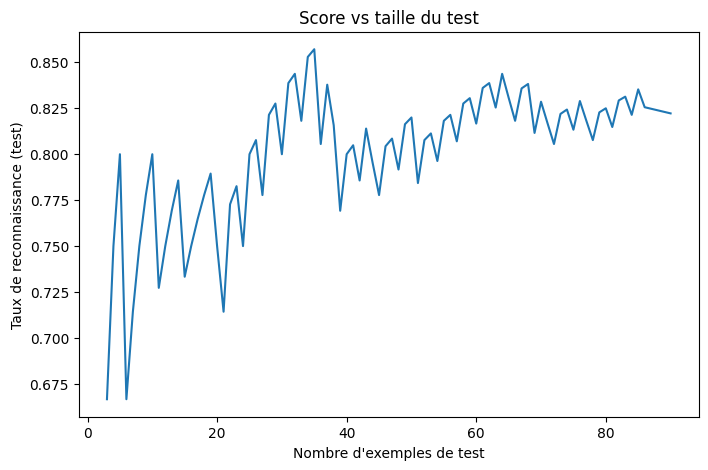

In [10]:
scores_3b = []
nb_test = []

one_NN = KNeighborsClassifier(n_neighbors=1, algorithm='brute')
one_NN.fit(X_train, y_train)

n_classes = len(np.unique(y_test))
n_total = len(X_test)

for p in np.arange(0.01, 1.01, 0.01):
    n = max(int(p * n_total), n_classes)

    # S'assurer qu'il reste aussi assez pour le "reste" de la split
    if n >= n_total - n_classes:
        X_test1, y_test1 = X_test, y_test
    else:
        X_test1, _, y_test1, _ = tts(
            X_test, y_test,
            train_size=n,
            stratify=y_test,
            random_state=42
        )

    score = one_NN.score(X_test1, y_test1)
    scores_3b.append(score)
    nb_test.append(len(X_test1))

plt.figure(figsize=(8, 5))
plt.plot(nb_test, scores_3b)
plt.xlabel("Nombre d'exemples de test")
plt.ylabel("Taux de reconnaissance (test)")
plt.title("Score vs taille du test")
plt.show()

# 8. Observations sur la Taille du Jeu de Test

Le score oscille fortement quand le test est petit (peu d'exemples → estimation bruitée)


Il converge et se stabilise quand le test grandit

# 9. Algorithme des K-Plus Proches Voisins (K-PPV)

Comment trouver le k idéal ?

Une règle classique souvent citée : k_max = √n = √210 ≈ 14. C'est une heuristique raisonnable. On va tester de 1 à ~30 pour bien voir le comportement.

# 10. Détermination du K Idéal

k* = 8 (score test = 88.89%)


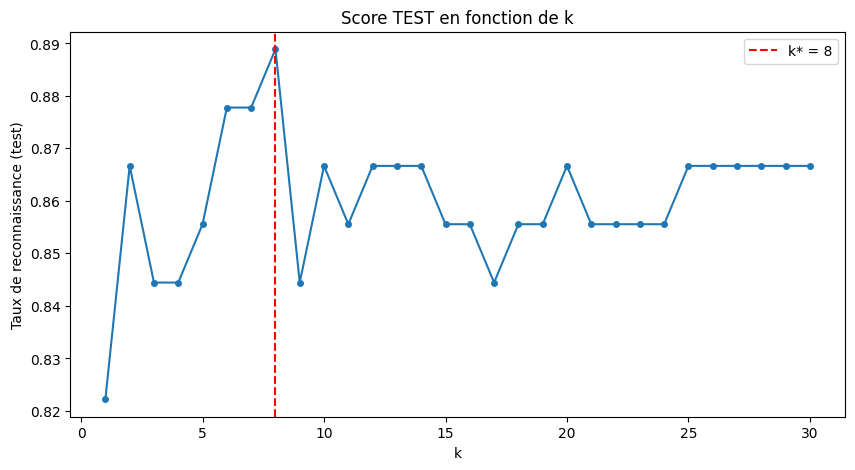

In [12]:
k_max = 30  # justification : bien au-delà de sqrt(210) ≈ 14

scores_test = []
scores_train = []

for k in range(1, k_max + 1):
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    knn.fit(X_train, y_train)
    scores_test.append(knn.score(X_test, y_test))
    scores_train.append(knn.score(X_train, y_train))

# Trouver k*
k_star = np.argmax(scores_test) + 1  # +1 car range commence à 1
print(f"k* = {k_star} (score test = {max(scores_test):.2%})")

# Tracer le score en TEST (question 4b)
plt.figure(figsize=(10, 5))
plt.plot(range(1, k_max + 1), scores_test, marker='o', markersize=4)
plt.xlabel("k")
plt.ylabel("Taux de reconnaissance (test)")
plt.title("Score TEST en fonction de k")
plt.axvline(x=k_star, color='r', linestyle='--', label=f'k* = {k_star}')
plt.legend()
plt.show()

# 11. Évaluation du Score en Test en Fonction de K

 Le score en test monte depuis k=1, atteint un maximum à k* ici k=8, puis redescend. C'est la courbe en "U inversé" typique du compromis biais/variance.

# 12. Visualisation des Frontières de Décision pour Différents K

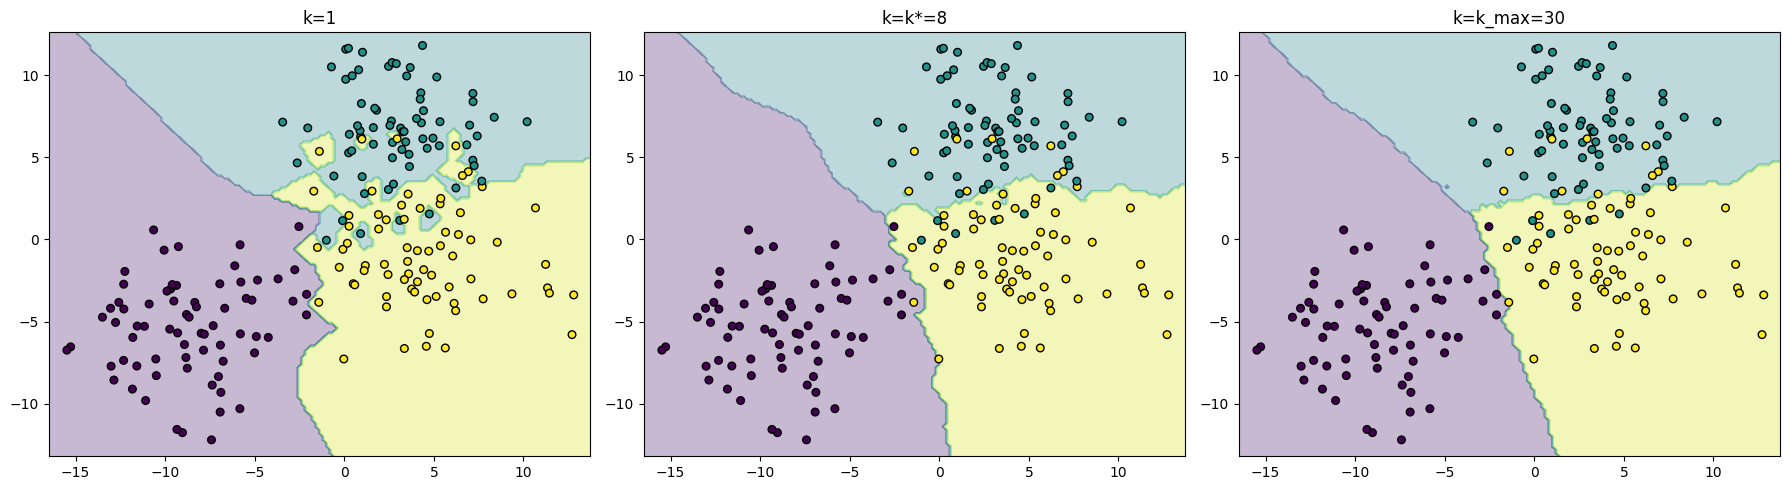

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k, label in zip(axes, [1, k_star, k_max],
                          [f"k=1", f"k=k*={k_star}", f"k=k_max={k_max}"]):
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    knn.fit(X_train, y_train)

    h = 0.2
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap='viridis', edgecolors='k', s=30)
    ax.set_title(label)

plt.tight_layout()
plt.show()

# 13. Évaluation du Score en Apprentissage en Fonction de K

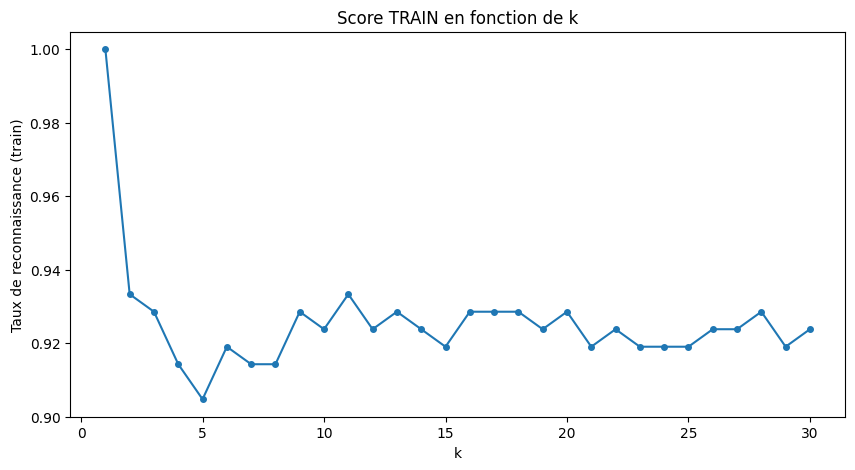

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, k_max + 1), scores_train, marker='o', markersize=4)
plt.xlabel("k")
plt.ylabel("Taux de reconnaissance (train)")
plt.title("Score TRAIN en fonction de k")
plt.show()


* À **k=1** : score train = 100% — chaque point est son propre voisin le plus proche, donc toujours bien classé. C'est du surapprentissage pur.
* Quand **k augmente** : le score train descend progressivement, car on consulte des voisins de classes différentes qui "polluent" le vote.
* Contrairement au score test qui forme un U inversé, le score train est **monotone décroissant** : plus k est grand, plus le modèle est lisse et moins il mémorise les données d'apprentissage.

# 14. Discussion sur le Protocole d'Évaluation

 Le protocole est-il satisfaisant ?


La réponse est NON, et c'est un piège d'exam. Pourquoi ? Parce qu'on a utilisé le test pour choisir k*. On a sélectionné le k qui maximise le score sur le test → on a "triché" : le test n'est plus indépendant, il a servi à régler un hyperparamètre.
Le bon protocole serait de découper en 3 parties : train / validation / test. On utilise la validation pour choisir k*, et le test (jamais touché) pour l'évaluation finale. Encore mieux : la validation croisée (cross-validation), qui réutilise toutes les données en alternant les rôles.